# ⚡ Concurrent Agent Workflows with Microsoft Foundry (Python)

## 📋 Advanced Parallel Processing Tutorial

This notebook demonstrates **concurrent workflow patterns** using the Microsoft Agent Framework. You'll learn how to build high-performance, parallel processing workflows where multiple AI agents execute simultaneously, dramatically improving throughput and enabling sophisticated multi-threaded business processes.

> **Migration note:** This sample previously referenced GitHub Models. GitHub Models is deprecated (retiring July 2026), so it now uses **Microsoft Foundry** through the `FoundryChatClient`, which targets the Azure OpenAI **Responses API**.

## 🎯 Learning Objectives

### 🚀 **Concurrent Processing Fundamentals**
- **Parallel Agent Execution**: Run multiple agents simultaneously for maximum efficiency
- **Workflow Orchestration**: Coordinate concurrent operations while maintaining data consistency
- **Performance Optimization**: Achieve significant speedup through parallel processing
- **Resource Management**: Efficiently utilize AI model resources across concurrent operations

### 🏗️ **Advanced Concurrency Patterns**
- **Fork-Join Processing**: Split work across multiple agents and merge results
- **Pipeline Parallelism**: Overlapping execution stages for continuous throughput
- **Load Balancing**: Distribute work evenly across available agent resources
- **Synchronization Points**: Coordinate concurrent agents at critical workflow stages

### 🏢 **Enterprise Concurrent Applications**
- **High-Volume Document Processing**: Process multiple documents simultaneously
- **Real-Time Content Analysis**: Concurrent analysis of incoming data streams
- **Batch Processing Optimization**: Maximize throughput for large-scale operations
- **Multi-Modal Analysis**: Parallel processing of different content types (text, images, data)

## ⚙️ Prerequisites & Setup

### 📦 **Required Dependencies**

Install Agent Framework with concurrent workflow capabilities:

```bash
pip install agent-framework -U
```

### 🔑 **Microsoft Foundry Configuration**

Sign in with the Azure CLI (`az login`) so `AzureCliCredential` can authenticate, then set your Microsoft Foundry project details.

**Environment Setup (.env file):**
```env
AZURE_AI_PROJECT_ENDPOINT=https://<your-project>.services.ai.azure.com
AZURE_AI_MODEL_DEPLOYMENT_NAME=gpt-4o-mini
```

**Concurrent Processing Considerations:**
- **Rate Limits**: Monitor Azure OpenAI rate limits for concurrent requests
- **Resource Usage**: Consider memory and CPU usage with multiple concurrent agents
- **Error Handling**: Implement robust error recovery for parallel operations

### 🏗️ **Concurrent Workflow Architecture**

```mermaid
graph TD
    A[Workflow Start] --> B[Concurrent Execution]
    B --> C[Agent Pool 1]
    B --> D[Agent Pool 2]
    B --> E[Agent Pool 3]
    C --> F[Result Aggregation]
    D --> F
    E --> F
    F --> G[Final Output]
    
    H[Microsoft Foundry] --> C
    H --> D
    H --> E
```

**Key Benefits:**
- **⚡ Performance**: Significant speedup through parallel execution
- **📈 Scalability**: Handle increased workloads without proportional time increase
- **🔄 Efficiency**: Better utilization of available computational resources
- **🎯 Throughput**: Process more work in the same amount of time

## 🎨 **Concurrent Workflow Design Patterns**

### 🔍 **Research & Analysis Pipeline**
```
Research Task → Parallel Research Agents → Content Synthesis → Quality Review
```

### 📊 **Data Processing Workflow**
```
Input Data → Concurrent Processing Agents → Result Aggregation → Final Report
```

### 🎭 **Content Creation Pipeline**
```
Content Brief → Parallel Content Generators → Review & Merge → Final Content
```

### 🔄 **Multi-Stage Processing**
```
Input → Stage 1 (Concurrent) → Stage 2 (Concurrent) → Stage 3 (Sequential) → Output
```

## 🏢 **Enterprise Performance Benefits**

### ⚡ **Throughput Optimization**
- **Parallel Execution**: Multiple agents working simultaneously
- **Resource Utilization**: Maximum efficiency of available AI model capacity
- **Time Reduction**: Significant decrease in total processing time
- **Scalable Architecture**: Easily add more concurrent agents as needed

### 🛡️ **Reliability & Resilience**
- **Fault Tolerance**: Individual agent failures don't stop the entire workflow
- **Error Isolation**: Problems in one concurrent branch don't affect others
- **Graceful Degradation**: System continues operating even with reduced agent capacity
- **Recovery Mechanisms**: Automatic retry and error handling for failed operations

### 📊 **Monitoring & Observability**
- **Concurrent Execution Tracking**: Monitor progress of all parallel operations
- **Performance Metrics**: Measure speedup and efficiency gains
- **Resource Usage Analytics**: Optimize concurrent agent allocation
- **Bottleneck Identification**: Find and resolve performance constraints

Let's build high-performance concurrent AI workflows! 🚀


In [ ]:
# Already covered by repo-level requirements.txt; left for reference.
# !pip install agent-framework -U

In [1]:
import os
from typing import Any

from agent_framework import (
    Executor,
    Message,
    WorkflowBuilder,
    WorkflowContext,
    WorkflowViz,
    handler,
)
from agent_framework.foundry import FoundryChatClient
from azure.identity import AzureCliCredential
from dotenv import load_dotenv

load_dotenv()


c:\Users\lujan\Proyectos\Cursos\ai-agents-for-beginners\.venv\Lib\site-packages\agent_framework\_skills.py:122: ExperimentalWarning: [SKILLS] SkillResource is experimental and may change or be removed in future versions without notice.
c:\Users\lujan\Proyectos\Cursos\ai-agents-for-beginners\.venv\Lib\site-packages\agent_framework\_harness\_file_access.py:602: ExperimentalWarning: [HARNESS] AgentFileStore is experimental and may change or be removed in future versions without notice.


True

In [2]:
# Configure the Microsoft Foundry client with keyless authentication.
# FoundryChatClient targets the Azure OpenAI Responses API.
provider = FoundryChatClient(
    project_endpoint=os.environ["AZURE_AI_PROJECT_ENDPOINT"],
    model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
    credential=AzureCliCredential(),
)


In [3]:
ResearcherAgentName = "Researcher-Agent"
ResearcherAgentInstructions = "You are my travel researcher, working with me to analyze the destination, list relevant attractions, and make detailed plans for each attraction."

In [4]:
PlanAgentName = "Plan-Agent"
PlanAgentInstructions = "You are my travel planner, working with me to create a detailed travel plan based on the researcher's findings."

In [5]:
research_agent = provider.as_agent(
    name=ResearcherAgentName,
    instructions=ResearcherAgentInstructions,
)

plan_agent = provider.as_agent(
    name=PlanAgentName,
    instructions=PlanAgentInstructions,
)


In [6]:
# A passthrough executor that broadcasts the user input to every agent in parallel.
class InputDispatcher(Executor):
    """Forward the user input unchanged to all participating agents."""

    @handler
    async def forward(self, text: str, ctx: WorkflowContext[str]) -> None:
        await ctx.send_message(text)


dispatcher = InputDispatcher(id="dispatcher")
agents = [research_agent, plan_agent]

workflow = (
    WorkflowBuilder(
        start_executor=dispatcher,
        output_executors=agents,
    )
    .add_fan_out_edges(dispatcher, agents)
    .build()
)

C:\Users\lujan\AppData\Local\Temp\ipykernel_8240\3870586217.py:14: DeprecationWarning: `output_executors` is deprecated and will be removed in a future version; use `output_from` instead.
  WorkflowBuilder(


In [8]:
import os

# Le indicamos a Python la ruta exacta de Graphviz en Windows
ruta_graphviz = r"C:\Program Files\Graphviz\bin"

if ruta_graphviz not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + ruta_graphviz
    print("¡Ruta de Graphviz añadida con éxito a esta sesión!")
else:
    print("La ruta de Graphviz ya estaba configurada.")

¡Ruta de Graphviz añadida con éxito a esta sesión!


In [9]:
print("Generating workflow visualization...")
viz = WorkflowViz(workflow)
# Print out the mermaid string.
print("Mermaid string: \n=======")
print(viz.to_mermaid())
print("=======")
# Print out the DiGraph string.
print("DiGraph string: \n=======")
print(viz.to_digraph())
print("=======")
# SVG export needs the optional graphviz extra plus the graphviz system binary;
# fall back gracefully if it is not available.
try:
    svg_file = viz.export(format="svg")
    print(f"SVG file saved to: {svg_file}")
except ImportError as e:
    svg_file = None
    print(f"SVG export skipped (install graphviz to enable): {e}")

Generating workflow visualization...
Mermaid string: 
flowchart TD
  dispatcher["dispatcher (Start)"];
  Researcher_Agent["Researcher-Agent"];
  Plan_Agent["Plan-Agent"];
  dispatcher --> Researcher_Agent;
  dispatcher --> Plan_Agent;
DiGraph string: 
digraph Workflow {
  rankdir=TD;
  node [shape=box, style=filled, fillcolor=lightblue];
  edge [color=black, arrowhead=vee];

  "dispatcher" [fillcolor=lightgreen, label="dispatcher\n(Start)"];
  "Researcher-Agent" [label="Researcher-Agent"];
  "Plan-Agent" [label="Plan-Agent"];
  "dispatcher" -> "Researcher-Agent";
  "dispatcher" -> "Plan-Agent";
}
SVG file saved to: C:\Users\lujan\AppData\Local\Temp\tmpyrla4ecb.svg


Attempting to display SVG file at: C:\Users\lujan\AppData\Local\Temp\tmpyrla4ecb.svg


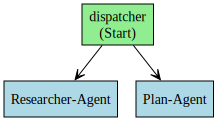

In [10]:
from IPython.display import SVG, display, HTML
import os

print(f"Attempting to display SVG file at: {svg_file}")

if svg_file and os.path.exists(svg_file):
    try:
        # Preferred: direct SVG rendering
        display(SVG(filename=svg_file))
    except Exception as e:
        print(f"⚠️ Direct SVG render failed: {e}. Falling back to raw HTML.")
        try:
            with open(svg_file, "r", encoding="utf-8") as f:
                svg_text = f.read()
            display(HTML(svg_text))
        except Exception as inner:
            print(f"❌ Fallback HTML render also failed: {inner}")
else:
    print("❌ SVG file not found. Ensure viz.export(format='svg') ran successfully.")

In [11]:
events = await workflow.run("Plan a trip to Seattle in December")
outputs = events.get_outputs()

AgentExecutor 'Researcher-Agent': from_str handler invoked with an empty cache. If you are chaining from an AgentExecutor, the upstream custom executor may be emitting a plain str instead of using AgentExecutorResponse.with_text(...), which causes the full conversation context to be lost.
AgentExecutor 'Plan-Agent': from_str handler invoked with an empty cache. If you are chaining from an AgentExecutor, the upstream custom executor may be emitting a plain str instead of using AgentExecutorResponse.with_text(...), which causes the full conversation context to be lost.


In [12]:
if outputs:
    print("===== Final Aggregated Responses =====")
    # outputs is a list of AgentResponse objects, one per output executor
    # (research_agent then plan_agent), in the order given to output_executors.
    for i, response in enumerate(outputs, start=1):
        print(f"{'-' * 60}\n\n{i:02d}:\n{response.text}")

===== Final Aggregated Responses =====
------------------------------------------------------------

01:
Great — I can put together a detailed December trip plan to Seattle. Below is a ready-to-use plan with weather/packing tips, neighborhood and lodging guidance, transportation, sample 3- and 5-day itineraries (with timing and booking tips), holiday/event ideas, dining picks, budget estimates, and next steps. Tell me your travel dates, group size, budget, and interests (food, museums, outdoors, day trips, holiday markets) and I’ll tailor it.

Quick overview — what to expect in Seattle in December
- Weather: cool and wet. Average highs in the 40s–50s°F (5–12°C), lows in the upper 30s–40s°F (3–7°C). Frequent rain and gray skies; light snow is possible but uncommon at sea level.
- Daylight: short days — plan for limited daylight (sunset ~4:15–4:30 PM).
- Crowd levels: downtown tourist spots quieter than summer but holiday events and weekend markets can be busy. Book key attractions and r